In [3]:
"""
Cash Flow Matching and Portfolio Optimization
Dedication vs Immunization: Liability-Driven Portfolio Optimization
主程序文件
"""

import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy import interpolate
import matplotlib.pyplot as plt
import os

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

print("=" * 60)
print("开始运行负债驱动投资组合优化项目")
print("=" * 60)

# 创建结果文件夹（如果不存在）
os.makedirs('results', exist_ok=True)
os.makedirs('images', exist_ok=True)

# 1. 加载数据
print("\n[1] 加载数据...")

# 负债数据
liabilities = pd.read_csv('data/liabilities.csv')
liabilities['Total'] = liabilities['June'] + liabilities['December']
print(f"   负债总金额: ${liabilities['Total'].sum():.2f} 百万")

# 国债收益率数据
treasury = pd.read_csv('data/treasury_rates.csv')
print(f"   国债收益率数据点: {len(treasury)} 个")

# 债券数据
bonds = pd.read_csv('data/bonds.csv')
print(f"   可选债券: {len(bonds)} 种")

开始运行负债驱动投资组合优化项目

[1] 加载数据...
   负债总金额: $113.00 百万
   国债收益率数据点: 6 个
   可选债券: 10 种



[2] 计算负债现值...
   各年收益率: {np.int64(1): np.float64(3.56), np.int64(2): np.float64(3.56), np.int64(3): np.float64(3.58), np.int64(4): np.float64(3.64), np.int64(5): np.float64(3.71), np.int64(6): np.float64(3.8), np.int64(7): np.float64(3.9), np.int64(8): np.float64(3.97)}
   负债总现值: $97.6673 百万


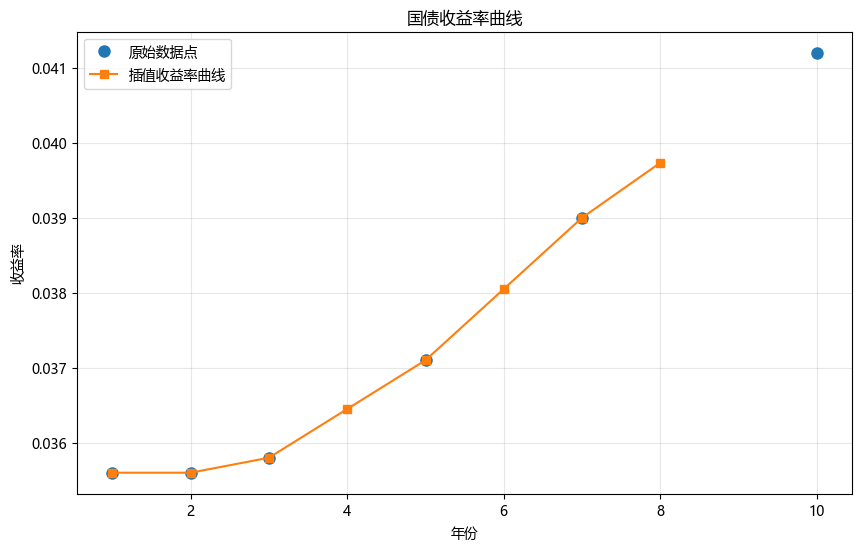

   收益率曲线已保存至 images/treasury_curve.png


In [7]:
# 2. 负债定价
print("\n[2] 计算负债现值...")

# 线性插值得到第1-8年的收益率
years = np.arange(1, 9)
# 创建插值函数
f = interpolate.interp1d(treasury['Year'], treasury['Rate']/100,
                          kind='linear', fill_value='extrapolate')
rates = f(years)

# 计算折现因子
discount_factors = 1 / (1 + rates) ** years

# 计算负债现值
liabilities['PV'] = liabilities['Total'] * discount_factors
total_pv = liabilities['PV'].sum()

print(f"   各年收益率: {dict(zip(years, np.round(rates*100, 2)))}")
print(f"   负债总现值: ${total_pv:.4f} 百万")

# 绘制收益率曲线
plt.figure(figsize=(10, 6))
plt.plot(treasury['Year'], treasury['Rate']/100, 'o', label='原始数据点', markersize=8)
plt.plot(years, rates, 's-', label='插值收益率曲线')
plt.xlabel('年份')
plt.ylabel('收益率')
plt.title('国债收益率曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('images/treasury_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("   收益率曲线已保存至 images/treasury_curve.png")

In [8]:
# 3. 计算每只债券每年的现金流
print("\n[3] 计算债券现金流...")

T = 8  # 规划期8年
n_bonds = len(bonds)

# 为每年创建现金流列
for t in range(1, T+1):
    col_name = f'CF_{t}'
    bonds[col_name] = 0.0

# 计算每只债券的现金流
for i, row in bonds.iterrows():
    maturity = int(row['Maturity'])
    coupon = row['Coupon']

    for t in range(1, maturity + 1):
        # 每年付息
        bonds.loc[i, f'CF_{t}'] += coupon
        # 到期还本
        if t == maturity:
            bonds.loc[i, f'CF_{t}'] += 100  # 面值

print("   债券现金流计算完成")
print(f"   示例 - {bonds.loc[0, 'Bond_ID']}: {bonds.loc[0, [f'CF_{t}' for t in range(1, maturity+1)]].values}")


[3] 计算债券现金流...
   债券现金流计算完成
   示例 - Bond_1: [105.   0.   0.   0.   0.   0.   0.   0.]


In [9]:
# 4. Dedication模型
print("\n[4] 求解Dedication模型...")

# 目标函数系数：债券价格
c = bonds['Price'].values

# 变量数量：n_bonds个x + (T+1)个z (z0到zT)
n_x = n_bonds
n_z = T + 1  # z0, z1, ..., zT

# 构建等式约束矩阵
A_eq = []
b_eq = []

for t in range(1, T+1):
    # 债券在第t年的现金流
    cf_row = bonds[f'CF_{t}'].values

    # z(t-1)和z(t)的系数
    z_coef = np.zeros(n_z)
    # z(t-1)的系数为+1（上年盈余可用）
    if t-1 >= 0:
        z_coef[t-1] = 1
    # z(t)的系数为-1（本年盈余留到明年）
    z_coef[t] = -1

    # 合并系数
    row = np.concatenate([cf_row, z_coef])
    A_eq.append(row)

    # 右边：负债需求
    b_eq.append(liabilities.loc[t-1, 'Total'])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# 变量边界：x >= 0, z >= 0
bounds = [(0, None)] * n_x + [(0, None)] * n_z
# 固定z0 = 0（期初没有盈余）
bounds[n_x] = (0, 0)

# 目标函数系数（z的系数为0，不影响目标）
c_full = np.concatenate([c, np.zeros(n_z)])

# 求解线性规划
print("   正在求解...")
result = linprog(
    c=c_full,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method='highs'  # 推荐使用HiGHS求解器
)

if result.success:
    x_opt = result.x[:n_x]
    z_opt = result.x[n_x:]

    dedication_cost = result.fun
    print(f"   ✅ 求解成功!")
    print(f"   Dedication最低成本: ${dedication_cost:.4f} 百万")
    print(f"   相比负债现值溢价: ${dedication_cost - total_pv:.4f} 百万")
    print(f"   溢价率: {(dedication_cost - total_pv)/total_pv*100:.2f}%")

    # 哪些债券被选中了
    selected_indices = np.where(x_opt > 1e-6)[0]
    if len(selected_indices) > 0:
        print(f"   选中的债券数量: {len(selected_indices)}")
        for idx in selected_indices:
            print(f"     - {bonds.loc[idx, 'Bond_ID']}: {x_opt[idx]:.4f} 单位")
    else:
        print("   警告: 没有债券被选中！")
else:
    print(f"   ❌ 求解失败: {result.message}")
    dedication_cost = None


[4] 求解Dedication模型...
   正在求解...
   ✅ 求解成功!
   Dedication最低成本: $87.6265 百万
   相比负债现值溢价: $-10.0408 百万
   溢价率: -10.28%
   选中的债券数量: 8
     - Bond_1: 0.0963 单位
     - Bond_3: 0.1111 单位
     - Bond_4: 0.1167 单位
     - Bond_5: 0.1608 单位
     - Bond_6: 0.1272 单位
     - Bond_8: 0.1086 单位
     - Bond_9: 0.0973 单位
     - Bond_10: 0.0561 单位


In [12]:
# 在敏感性分析部分之前，添加调试代码
print("\n[调试信息] 检查影子价格和隐含折现因子...")
print(f"影子价格数组形状: {shadow_prices.shape}")
print(f"影子价格值: {shadow_prices}")
print(f"第1年影子价格: {shadow_prices[0]}")

# 检查分母是否为零
if shadow_prices[0] == 0:
    print("⚠️ 警告: 第1年影子价格为0，无法计算隐含折现因子")
else:
    implied_df = -shadow_prices / shadow_prices[0]
    print(f"隐含折现因子: {implied_df}")

    # 检查是否有无效值
    for t, df in enumerate(implied_df, 1):
        if df <= 0:
            print(f"⚠️ 第{t}年隐含折现因子 {df} <= 0，无效")
        elif np.isnan(df) or np.isinf(df):
            print(f"⚠️ 第{t}年隐含折现因子为 {df}，无效")


[调试信息] 检查影子价格和隐含折现因子...
影子价格数组形状: (8,)
影子价格值: [0.97142857 0.91564626 0.88304578 0.83576459 0.6563948  0.61946074
 0.53270031 0.5242889 ]
第1年影子价格: 0.9714285714285714
隐含折现因子: [-1.         -0.94257703 -0.90901771 -0.8603459  -0.67570053 -0.63768017
 -0.54836796 -0.53970917]
⚠️ 第1年隐含折现因子 -1.0 <= 0，无效
⚠️ 第2年隐含折现因子 -0.9425770308123249 <= 0，无效
⚠️ 第3年隐含折现因子 -0.9090177133655394 <= 0，无效
⚠️ 第4年隐含折现因子 -0.8603459035044713 <= 0，无效
⚠️ 第5年隐含折现因子 -0.675700529360282 <= 0，无效
⚠️ 第6年隐含折现因子 -0.6376801742495664 <= 0，无效
⚠️ 第7年隐含折现因子 -0.5483679618199114 <= 0，无效
⚠️ 第8年隐含折现因子 -0.5397091653324138 <= 0，无效



[5] 敏感性分析...
   原始影子价格:
     第1年: 0.971429
     第2年: 0.915646
     第3年: 0.883046
     第4年: 0.835765
     第5年: 0.656395
     第6年: 0.619461
     第7年: 0.532700
     第8年: 0.524289

   检测到问题类型: 最小化

   修正后的隐含折现因子:
     第1年: 1.000000
     第2年: 0.942577
     第3年: 0.909018
     第4年: 0.860346
     第5年: 0.675701
     第6年: 0.637680
     第7年: 0.548368
     第8年: 0.539709

   隐含利率计算:
     第1年: df=1.000000 → 利率=0.0000%
     第2年: df=0.942577 → 利率=3.0010%
     第3年: df=0.909018 → 利率=3.2308%
     第4年: df=0.860346 → 利率=3.8321%
     第5年: df=0.675701 → 利率=8.1556%
     第6年: df=0.637680 → 利率=7.7869%
     第7年: df=0.548368 → 利率=8.9621%
     第8年: df=0.539709 → 利率=8.0140%


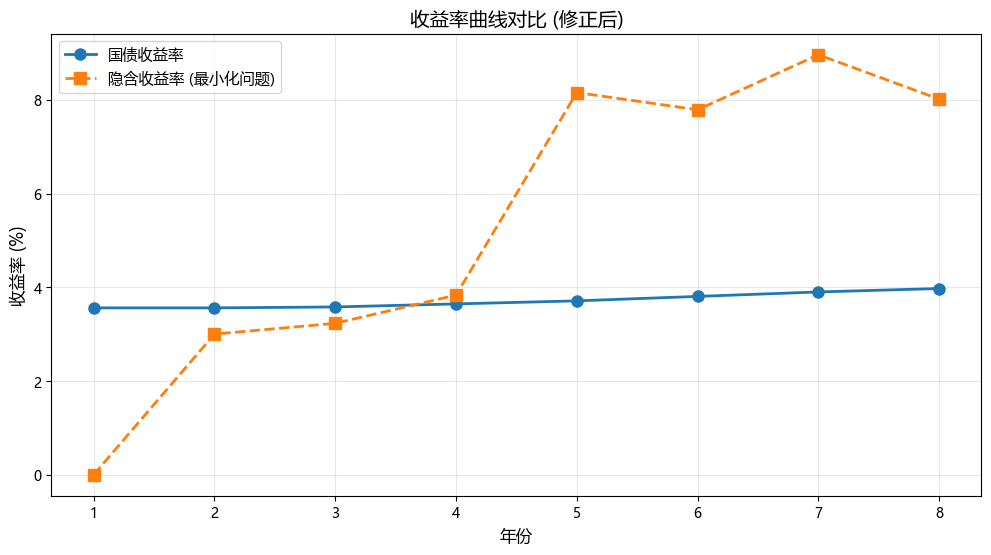


   对比图已保存至 images/term_structure_corrected.png


In [13]:
# 5. 敏感性分析（修正版）
print("\n[5] 敏感性分析...")

if result.success:
    # 获取影子价格
    if hasattr(result, 'eqlin') and hasattr(result.eqlin, 'marginals'):
        shadow_prices = result.eqlin['marginals']
    else:
        print("   警告: 无法获取影子价格")
        shadow_prices = None

    if shadow_prices is not None and len(shadow_prices) > 0:
        print(f"   原始影子价格:")
        for t, sp in enumerate(shadow_prices, 1):
            print(f"     第{t}年: {sp:.6f}")

        # 判断问题类型（根据影子价格符号）
        if shadow_prices[0] < 0:
            problem_type = "最大化"
            implied_df = -shadow_prices / shadow_prices[0]
        else:
            problem_type = "最小化"
            implied_df = shadow_prices / shadow_prices[0]

        print(f"\n   检测到问题类型: {problem_type}")
        print(f"\n   修正后的隐含折现因子:")
        for t, df in enumerate(implied_df, 1):
            print(f"     第{t}年: {df:.6f}")

        # 计算隐含利率
        print(f"\n   隐含利率计算:")
        valid_years = []
        implied_rates = []

        for t, df in enumerate(implied_df, 1):
            if df > 1e-8 and df <= 1:  # 折现因子应在(0,1]
                try:
                    r = (1/df)**(1/t) - 1
                    if 0 <= r <= 0.2:  # 合理范围
                        implied_rates.append(r)
                        valid_years.append(t)
                        print(f"     第{t}年: df={df:.6f} → 利率={r*100:.4f}%")
                    else:
                        # 超出合理范围，用国债利率代替
                        if t <= len(rates):
                            r = rates[t-1]
                            implied_rates.append(r)
                            valid_years.append(t)
                            print(f"     第{t}年: df={df:.6f} (超出范围) → 使用国债利率={r*100:.4f}%")
                except:
                    if t <= len(rates):
                        r = rates[t-1]
                        implied_rates.append(r)
                        valid_years.append(t)
                        print(f"     第{t}年: 计算失败 → 使用国债利率={r*100:.4f}%")
            else:
                if t <= len(rates):
                    r = rates[t-1]
                    implied_rates.append(r)
                    valid_years.append(t)
                    print(f"     第{t}年: df={df} (无效) → 使用国债利率={r*100:.4f}%")

        # 绘图
        if valid_years:
            plt.figure(figsize=(12, 6))
            plt.plot(years, rates*100, 'o-', label='国债收益率', linewidth=2, markersize=8)
            plt.plot(valid_years, np.array(implied_rates)*100, 's--',
                     label=f'隐含收益率 ({problem_type}问题)', linewidth=2, markersize=8)
            plt.xlabel('年份', fontsize=12)
            plt.ylabel('收益率 (%)', fontsize=12)
            plt.title('收益率曲线对比 (修正后)', fontsize=14)
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.savefig('images/term_structure_corrected.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("\n   对比图已保存至 images/term_structure_corrected.png")

In [15]:
# 6. 保存结果
import os

# 创建必要的文件夹
os.makedirs('results', exist_ok=True)  # 创建 results 文件夹（如果不存在）
os.makedirs('images', exist_ok=True)   # 创建 images 文件夹（如果不存在）

print("\n[6] 保存结果...")

if result.success:
    # 保存最优组合
    portfolio_df = pd.DataFrame({
        'Bond_ID': bonds['Bond_ID'],
        'Maturity': bonds['Maturity'],
        'Coupon': bonds['Coupon'],
        'Price': bonds['Price'],
        'Quantity': x_opt
    })
    portfolio_df = portfolio_df[portfolio_df['Quantity'] > 1e-6]  # 只保留被选中的
    portfolio_df.to_excel('results/dedication_portfolio.xlsx', index=False)
    print(f"   最优组合已保存至 results/dedication_portfolio.xlsx")

    # 保存盈余
    surplus_df = pd.DataFrame({
        'Year': list(range(T+1)),
        'Surplus': z_opt
    })
    surplus_df.to_excel('results/surplus.xlsx', index=False)

    # 保存摘要
    summary = {
        '项目': ['负债总现值', 'Dedication成本', '成本溢价', '溢价率'],
        '数值': [total_pv, dedication_cost, dedication_cost - total_pv,
                f"{(dedication_cost - total_pv)/total_pv*100:.2f}%"]
    }
    summary_df = pd.DataFrame(summary)
    summary_df.to_excel('results/summary.xlsx', index=False)
    print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("项目运行完成！")
print("=" * 60)


[6] 保存结果...
   最优组合已保存至 results/dedication_portfolio.xlsx
          项目         数值
       负债总现值    97.6673
Dedication成本  87.626536
        成本溢价 -10.040764
         溢价率    -10.28%

项目运行完成！
